In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16 
from tensorflow.keras.utils import plot_model

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle


In [ ]:
IMG_SIZE = (224,224)   
BATCH_SIZE = 16 # drop to 4\
    

train_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\igles\OneDrive\Documents\CPE-313\HOA 7.2\archive\FastAI_ImageNet_v2\train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE) 

val_ds = tf.keras.utils.image_dataset_from_directory(
    r"C:\Users\igles\OneDrive\Documents\CPE-313\HOA 7.2\archive\FastAI_ImageNet_v2\val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)



AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 9469 files belonging to 10 classes.
Found 3925 files belonging to 10 classes.


In [ ]:
def buildvgg16(input_shape=(224, 224, 3), num_classes=10):
 model = models.Sequential(name="VGG16")


 model.add(layers.Input(shape=input_shape))
 model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1'))
 model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool'))

 model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1'))
 model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool'))

 model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1'))
 model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2'))
 model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool'))

 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv1'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv2'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv3'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool'))
 
 
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv1'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv2'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv3'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool'))

 model.add(layers.Flatten(name='flatten'))


 model.add(layers.Dense(4096, activation='relu', name='fc1'))
 model.add(layers.Dropout(0.5, name='drop1'))

 model.add(layers.Dense(4096, activation='relu', name='fc2'))
 model.add(layers.Dropout(0.5, name='drop2'))
 model.add(layers.Dense(num_classes, activation='softmax', name='predictions'))
 return model


In [8]:
model = buildvgg16(input_shape=(224, 224, 3), num_classes=10)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10


592/592 [==============================] - 157s 245ms/step - loss: 2.0041 - accuracy: 0.2795 - val_loss: 1.7534 - val_accuracy: 0.4201
Epoch 2/10
592/592 [==============================] - 135s 227ms/step - loss: 1.5807 - accuracy: 0.4616 - val_loss: 1.3788 - val_accuracy: 0.5371
Epoch 3/10
592/592 [==============================] - 136s 230ms/step - loss: 1.3384 - accuracy: 0.5486 - val_loss: 1.2327 - val_accuracy: 0.5901
Epoch 4/10
592/592 [==============================] - 134s 227ms/step - loss: 1.1669 - accuracy: 0.6114 - val_loss: 1.1770 - val_accuracy: 0.6227
Epoch 5/10
592/592 [==============================] - 133s 224ms/step - loss: 1.0650 - accuracy: 0.6472 - val_loss: 1.0694 - val_accuracy: 0.6629
Epoch 6/10
592/592 [==============================] - 136s 230ms/step - loss: 0.9391 - accuracy: 0.6966 - val_loss: 1.0506 - val_accuracy: 0.6724
Epoch 7/10
592/592 [==============================] - 134s 227ms/step - loss: 0.8478 - accuracy: 0.7305 - val_loss: 0.9653 - val_accura

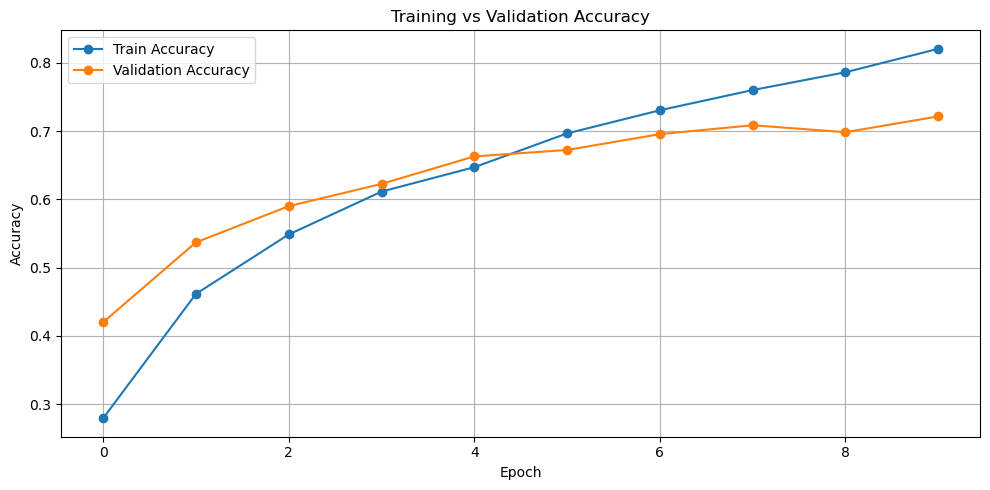

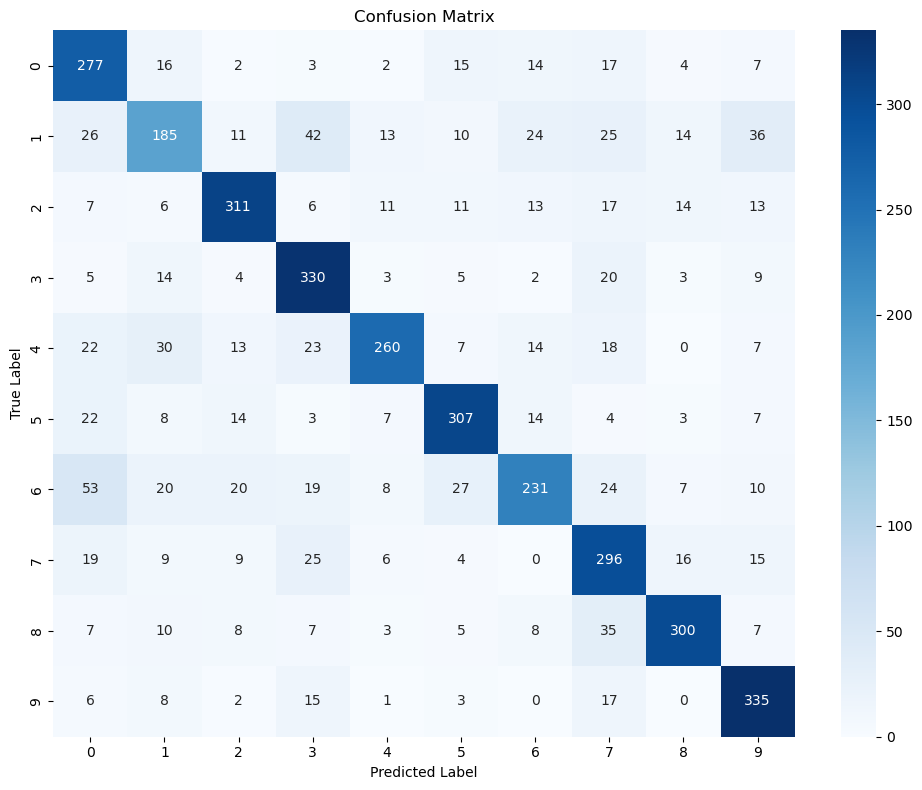


Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.78      0.69       357
           1       0.60      0.48      0.53       386
           2       0.79      0.76      0.77       409
           3       0.70      0.84      0.76       395
           4       0.83      0.66      0.73       394
           5       0.78      0.79      0.78       389
           6       0.72      0.55      0.63       419
           7       0.63      0.74      0.68       399
           8       0.83      0.77      0.80       390
           9       0.75      0.87      0.80       387

    accuracy                           0.72      3925
   macro avg       0.73      0.72      0.72      3925
weighted avg       0.73      0.72      0.72      3925



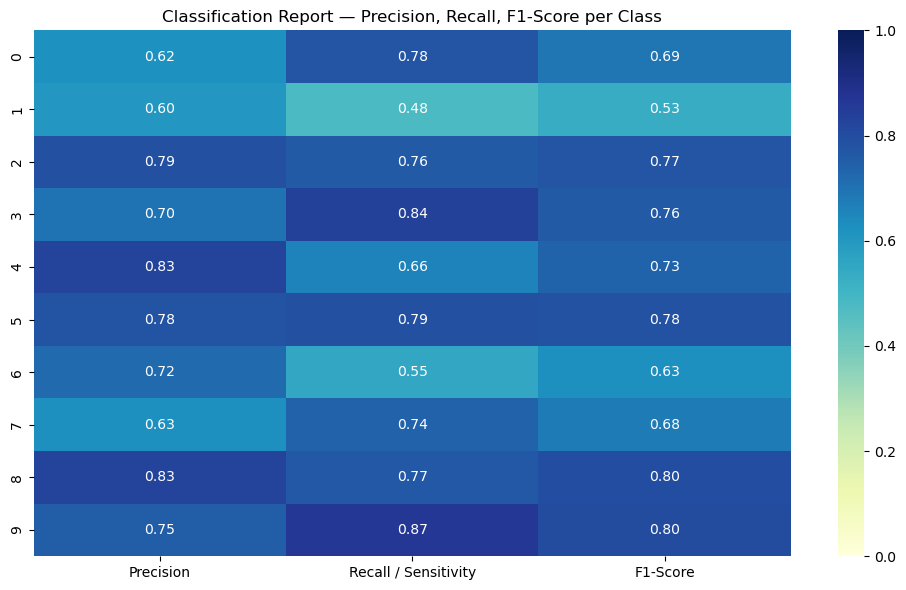


Macro-Average AUC: 0.9555


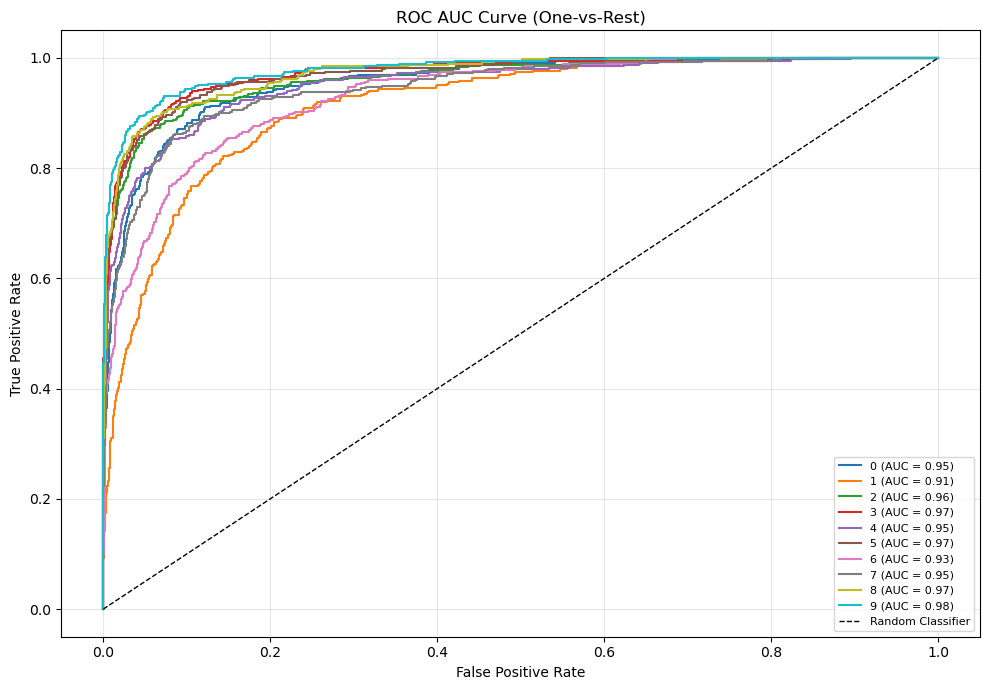

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize
import pandas as pd

# ── 1. ACCURACY PLOT ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'],     label='Train Accuracy',      marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy',  marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

# ── 2. GET TRUE LABELS & PREDICTIONS ─────────────────────────────────────────
y_true, y_pred_probs = [], []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Class names — replace with your actual class names if known
class_names = [str(i) for i in range(10)]
# e.g. class_names = ['class_0', 'class_1', ..., 'class_9']

# ── 3. CONFUSION MATRIX ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 4. CLASSIFICATION REPORT ─────────────────────────────────────────────────
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Sensitivity = Recall, so it's already included
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot as heatmap
metrics_df = report_df.loc[class_names, ['precision', 'recall', 'f1-score']]
metrics_df.columns = ['Precision', 'Recall / Sensitivity', 'F1-Score']

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df.astype(float), annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1)
plt.title('Classification Report — Precision, Recall, F1-Score per Class')
plt.tight_layout()
plt.savefig('classification_report.png', dpi=150)
plt.show()

# ── 5. ROC AUC CURVE (One-vs-Rest for multiclass) ────────────────────────────
y_true_bin = label_binarize(y_true, classes=list(range(10)))

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

auc_scores = []
for i, color in zip(range(10), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, color=color, lw=1.5,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

# Macro-average AUC
print(f"\nMacro-Average AUC: {np.mean(auc_scores):.4f}")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc.png', dpi=150)
plt.show()

# With pre trained model


In [17]:
from tensorflow.keras.applications import VGG16

In [19]:

base = tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = tf.keras.applications.vgg16.preprocess_input(inputs)
x       = base(x, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dense(256, activation='relu')(x)
x       = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)  

model = tf.keras.Model(inputs, outputs)


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()  


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 tf.__operators__.getitem (S  (None, 224, 224, 3)      0         
 licingOpLambda)                                                 
                                                                 
 tf.nn.bias_add (TFOpLambda)  (None, 224, 224, 3)      0         
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               131328

In [20]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
592/592 [==============================] - 38s 63ms/step - loss: 2.4470 - accuracy: 0.6474 - val_loss: 0.2621 - val_accuracy: 0.9236
Epoch 2/10
592/592 [==============================] - 36s 61ms/step - loss: 0.5300 - accuracy: 0.8716 - val_loss: 0.1888 - val_accuracy: 0.9445
Epoch 3/10
592/592 [==============================] - 36s 61ms/step - loss: 0.3524 - accuracy: 0.9057 - val_loss: 0.1592 - val_accuracy: 0.9521
Epoch 4/10
592/592 [==============================] - 36s 61ms/step - loss: 0.2478 - accuracy: 0.9271 - val_loss: 0.1417 - val_accuracy: 0.9554
Epoch 5/10
592/592 [==============================] - 37s 62ms/step - loss: 0.2032 - accuracy: 0.9371 - val_loss: 0.1309 - val_accuracy: 0.9587
Epoch 6/10
592/592 [==============================] - 36s 60ms/step - loss: 0.1536 - accuracy: 0.9524 - val_loss: 0.1184 - val_accuracy: 0.9620
Epoch 7/10
592/592 [==============================] - 36s 61ms/step - loss: 0.1425 - accuracy: 0.9559 - val_loss: 0.1128 - val_accuracy:

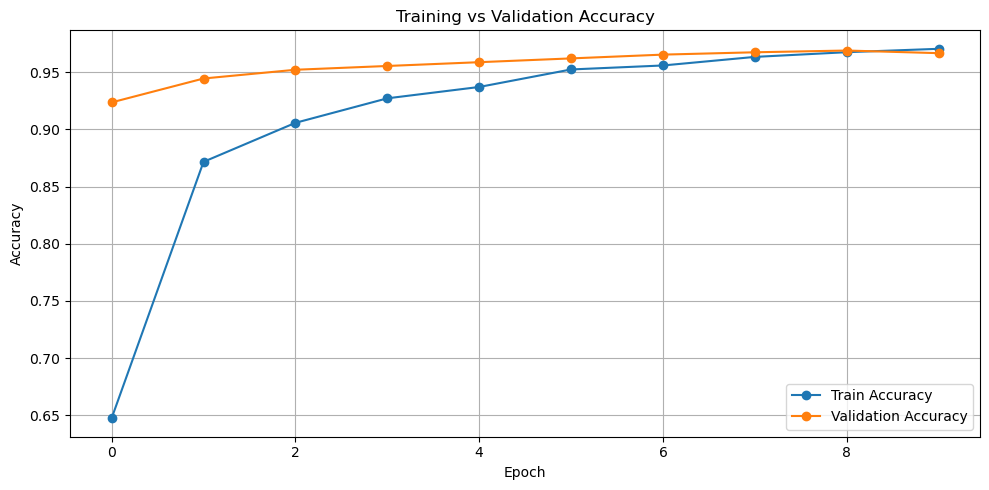

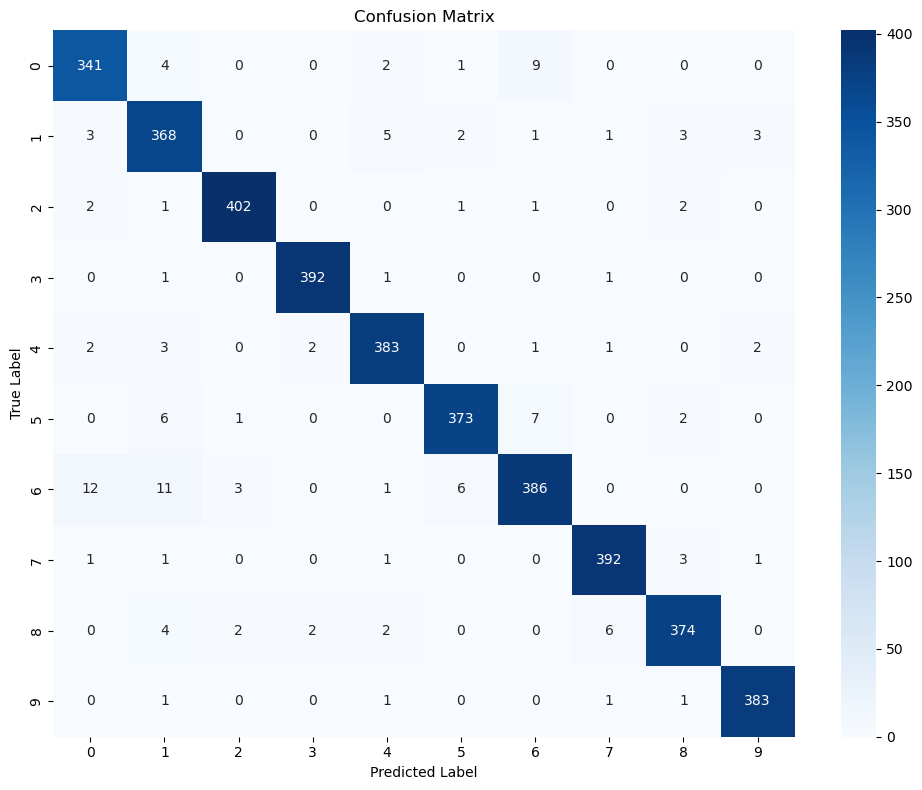


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       357
           1       0.92      0.95      0.94       386
           2       0.99      0.98      0.98       409
           3       0.99      0.99      0.99       395
           4       0.97      0.97      0.97       394
           5       0.97      0.96      0.97       389
           6       0.95      0.92      0.94       419
           7       0.98      0.98      0.98       399
           8       0.97      0.96      0.97       390
           9       0.98      0.99      0.99       387

    accuracy                           0.97      3925
   macro avg       0.97      0.97      0.97      3925
weighted avg       0.97      0.97      0.97      3925



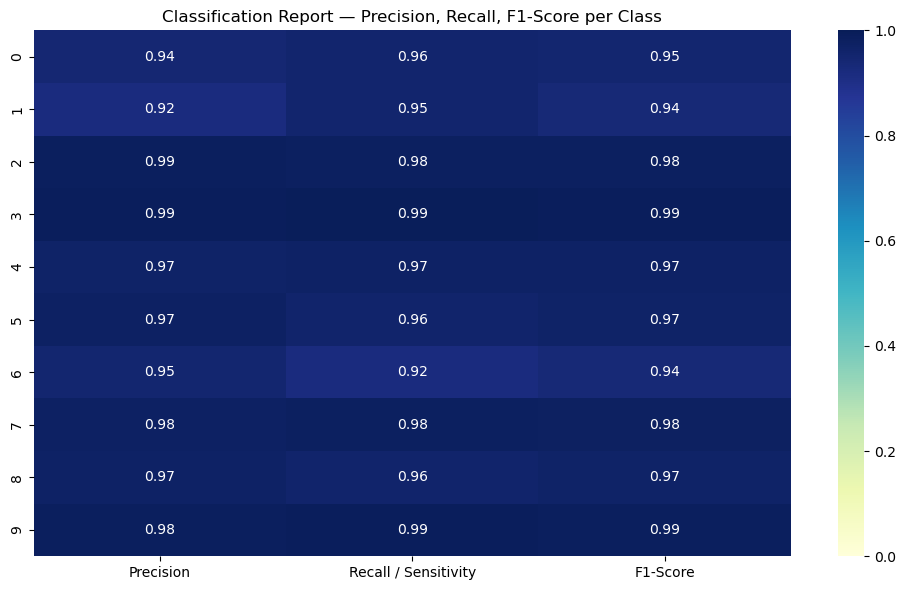


Macro-Average AUC: 0.9993


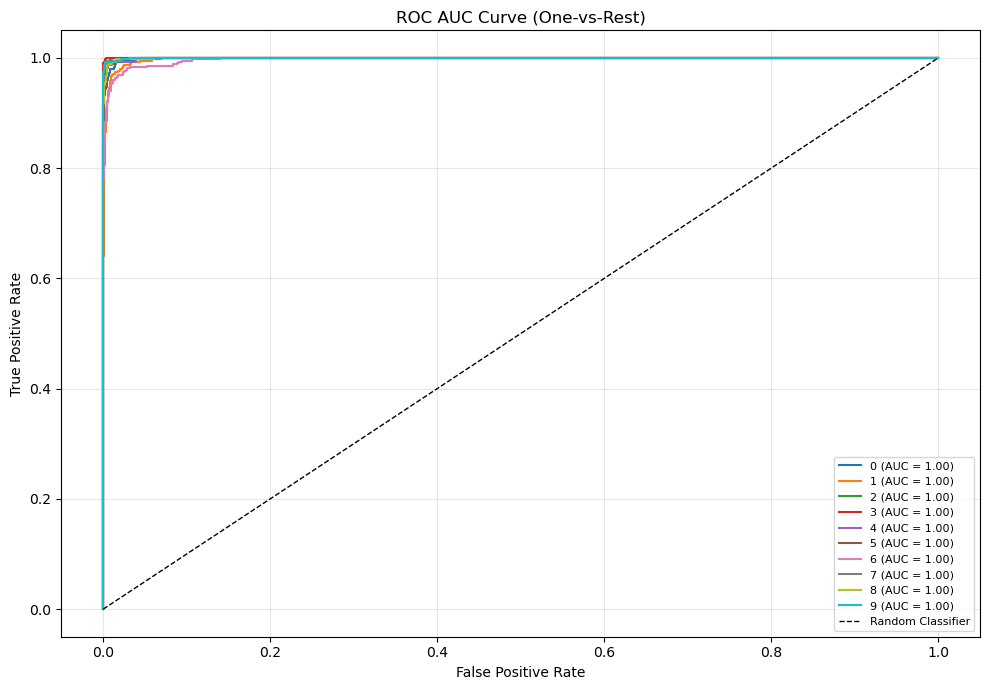

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, 
                             roc_curve, auc)
from sklearn.preprocessing import label_binarize
import pandas as pd

# ── 1. ACCURACY PLOT ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'],     label='Train Accuracy',      marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy',  marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

# ── 2. GET TRUE LABELS & PREDICTIONS ─────────────────────────────────────────
y_true, y_pred_probs = [], []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Class names — replace with your actual class names if known
class_names = [str(i) for i in range(10)]
# e.g. class_names = ['class_0', 'class_1', ..., 'class_9']

# ── 3. CONFUSION MATRIX ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
#plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 4. CLASSIFICATION REPORT ─────────────────────────────────────────────────
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Sensitivity = Recall, so it's already included
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot as heatmap
metrics_df = report_df.loc[class_names, ['precision', 'recall', 'f1-score']]
metrics_df.columns = ['Precision', 'Recall / Sensitivity', 'F1-Score']

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df.astype(float), annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1)
plt.title('Classification Report — Precision, Recall, F1-Score per Class')
plt.tight_layout()
#plt.savefig('classification_report.png', dpi=150)
plt.show()

# ── 5. ROC AUC CURVE (One-vs-Rest for multiclass) ────────────────────────────
y_true_bin = label_binarize(y_true, classes=list(range(10)))

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

auc_scores = []
for i, color in zip(range(10), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, color=color, lw=1.5,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

# Macro-average AUC
print(f"\nMacro-Average AUC: {np.mean(auc_scores):.4f}")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
#plt.savefig('roc_auc.png', dpi=150)
plt.show()